# Thermal PV Panel Binary Classifier — MobileNetV2 (Kaggle)

**Project:** UAV-Based Photovoltaic Panel Inspection  
**Task:** Binary classification — `no_anomaly` vs `anomaly`  
**Model:** MobileNetV2 (width=1.0, ImageNet pretrained)  
**Input:** 224×224×3 RGB (thermal colourmap preserved)  
**Export:** TFLite float16 for Pi 5 deployment  

**Dataset:** Merged PVF-10 + PVMD (ImageFolder layout)  
```
dataset/
  train/
    no_anomaly/
    anomaly/
  val/
    no_anomaly/
    anomaly/
  test/
    no_anomaly/
    anomaly/
```

## 0 — Environment & Reproducibility

In [24]:
# ── GPU Configuration (MUST be FIRST thing after imports) ──────────────────
import tensorflow as tf

# Configure GPU BEFORE doing anything else with TF
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow {tf.__version__} | GPUs: {[g.name for g in gpus]}')

if gpus:
    try:
        # Configure memory growth for all GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('Memory growth enabled')
    except RuntimeError as e:
        print(f'Note: {e}')
        print('Continuing with existing configuration...')

# Now do the rest of your imports and setup
import os, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from tensorflow import keras
from tensorflow.keras import layers, callbacks, mixed_precision
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow 2.19.0 | GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1']
Note: Physical devices cannot be modified after being initialized
Continuing with existing configuration...


## 1 — Configuration

In [27]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Adjust DATA_ROOT to point to your Kaggle dataset input path
DATA_ROOT   = Path('/kaggle/input/datasets/chellalaicha/thermal-unified/thermal_unified_processed')  # Update this path
TRAIN_DIR   = DATA_ROOT / 'train'
VAL_DIR     = DATA_ROOT / 'val'
TEST_DIR    = DATA_ROOT / 'test'
OUTPUT_DIR  = Path('/kaggle/working')

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE    = 224          # MobileNetV2 canonical resolution
BATCH_SIZE  = 32
NUM_CLASSES = 1            # binary → sigmoid output
DROPOUT     = 0.3

# Phase 1 — head only
LR_HEAD     = 1e-3
EPOCHS_HEAD = 10

# Phase 2 — unfreeze top-1/3 of base
LR_FINE1    = 3e-4
EPOCHS_FINE1= 10

# Phase 3 — unfreeze full base
LR_FINE2    = 5e-5
EPOCHS_FINE2= 10

# Define anomaly classes (all except no_anomaly)
ANOMALY_CLASSES = ['full_cold', 'hotspot', 'partial_cold']
NORMAL_CLASS = 'no_anomaly'
ALL_CLASSES = ANOMALY_CLASSES + [NORMAL_CLASS]  # ['full_cold', 'hotspot', 'partial_cold', 'no_anomaly']

print('Config OK')
print(f'  Train : {TRAIN_DIR}')
print(f'  Val   : {VAL_DIR}')
print(f'  Test  : {TEST_DIR}')
print(f'  Anomaly classes: {ANOMALY_CLASSES}')
print(f'  Normal class: {NORMAL_CLASS}')

Config OK
  Train : /kaggle/input/datasets/chellalaicha/thermal-unified/thermal_unified_processed/train
  Val   : /kaggle/input/datasets/chellalaicha/thermal-unified/thermal_unified_processed/val
  Test  : /kaggle/input/datasets/chellalaicha/thermal-unified/thermal_unified_processed/test
  Anomaly classes: ['full_cold', 'hotspot', 'partial_cold']
  Normal class: no_anomaly


## 2 — Dataset Loading & Class Weights

In [28]:
def make_dataset(directory, training=False, batch_size=BATCH_SIZE):
    """Load an ImageFolder-style directory with binary labels (0=anomaly, 1=no_anomaly)."""
    
    # First load with all 4 classes
    ds = keras.utils.image_dataset_from_directory(
        directory,
        labels='inferred',
        label_mode='int',           # Use int labels for multi-class first
        class_names=ALL_CLASSES,    # Specify all 4 classes in order
        color_mode='rgb',
        batch_size=batch_size,
        image_size=(IMG_SIZE, IMG_SIZE),
        shuffle=training,
        seed=SEED,
        interpolation='bilinear',
    )
    
    # Convert to binary labels: 0=anomaly (full_cold, hotspot, partial_cold), 1=no_anomaly
    # Get the original class indices
    class_names = ds.class_names  # Should be ['full_cold', 'hotspot', 'partial_cold', 'no_anomaly']
    
    # Create mapping: anomaly classes -> 0, no_anomaly -> 1
    def convert_to_binary(image, label):
        # label is 0,1,2,3 corresponding to the 4 classes
        # Convert: if label == 3 (no_anomaly) -> 1, else -> 0
        binary_label = tf.cast(tf.equal(label, 3), tf.float32)  # 1 for no_anomaly, 0 for anomaly
        return image, binary_label
    
    ds = ds.map(convert_to_binary, num_parallel_calls=tf.data.AUTOTUNE)
    
    return ds

# Create datasets
train_ds_raw = make_dataset(TRAIN_DIR, training=True)
val_ds_raw   = make_dataset(VAL_DIR,   training=False)
test_ds_raw  = make_dataset(TEST_DIR,  training=False)

print('Class index mapping (original):', ALL_CLASSES)
print('Binary mapping: anomaly (full_cold, hotspot, partial_cold) → 0, no_anomaly → 1')

# ── Class distribution ────────────────────────────────────────────────────────
def count_samples(directory):
    """Count samples for each class and also binary distribution."""
    counts = {cls: 0 for cls in ALL_CLASSES}
    for cls in ALL_CLASSES:
        p = Path(directory) / cls
        if p.exists():
            counts[cls] = len(list(p.glob('*.*')))
    return counts

def get_binary_counts(counts):
    """Convert multi-class counts to binary counts."""
    anomaly_count = sum(counts[cls] for cls in ANOMALY_CLASSES)
    normal_count = counts[NORMAL_CLASS]
    return {'anomaly': anomaly_count, 'no_anomaly': normal_count}

train_counts = count_samples(TRAIN_DIR)
val_counts   = count_samples(VAL_DIR)
test_counts  = count_samples(TEST_DIR)

print('\nMulti-class sample counts:')
for split, counts in [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]:
    total = sum(counts.values())
    print(f'  {split}: {counts}  → total {total}')

print('\nBinary sample counts (anomaly vs no_anomaly):')
for split, counts in [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]:
    binary_counts = get_binary_counts(counts)
    total = sum(binary_counts.values())
    print(f'  {split}: {binary_counts}  → total {total}')

# ── Class weights (handles imbalance) ─────────────────────────────────────────
# Now binary: anomaly (class 0), no_anomaly (class 1)
n_anomaly_bin = get_binary_counts(train_counts)['anomaly']
n_no_anomaly_bin = get_binary_counts(train_counts)['no_anomaly']

# sklearn-style balanced weights
y_train_flat = ([0] * n_anomaly_bin) + ([1] * n_no_anomaly_bin)
cw = compute_class_weight('balanced', classes=np.array([0, 1]), 
                           y=np.array(y_train_flat))
class_weight = {0: cw[0], 1: cw[1]}

print(f'\nBinary class distribution:')
print(f'  Anomaly (class 0): {n_anomaly_bin} samples')
print(f'  No_anomaly (class 1): {n_no_anomaly_bin} samples')
print(f'  Class weights: {class_weight}')

# Verify dataset works
sample_images, sample_labels = next(iter(train_ds_raw.take(1)))
print(f'\nSample batch shape: {sample_images.shape}')
print(f'Sample labels (0=anomaly, 1=no_anomaly): {sample_labels[:10].numpy().flatten()}')

Found 7515 files belonging to 4 classes.
Found 1611 files belonging to 4 classes.
Found 1613 files belonging to 4 classes.
Class index mapping (original): ['full_cold', 'hotspot', 'partial_cold', 'no_anomaly']
Binary mapping: anomaly (full_cold, hotspot, partial_cold) → 0, no_anomaly → 1

Multi-class sample counts:
  Train: {'full_cold': 1249, 'hotspot': 2231, 'partial_cold': 846, 'no_anomaly': 3189}  → total 7515
  Val: {'full_cold': 268, 'hotspot': 478, 'partial_cold': 181, 'no_anomaly': 684}  → total 1611
  Test: {'full_cold': 268, 'hotspot': 479, 'partial_cold': 182, 'no_anomaly': 684}  → total 1613

Binary sample counts (anomaly vs no_anomaly):
  Train: {'anomaly': 4326, 'no_anomaly': 3189}  → total 7515
  Val: {'anomaly': 927, 'no_anomaly': 684}  → total 1611
  Test: {'anomaly': 929, 'no_anomaly': 684}  → total 1613

Binary class distribution:
  Anomaly (class 0): 4326 samples
  No_anomaly (class 1): 3189 samples
  Class weights: {0: np.float64(0.8685852981969486), 1: np.float64(

## 3 — Augmentation Pipeline

Two-stage strategy:
1. **Geometric** — flip, rotation, zoom (invariant to panel orientation)
2. **Colormap jitter** — hue/saturation shifts to bridge the PVF-10 vs PVMD colormap domain gap (iron vs rainbow palettes)

Pipelines built.


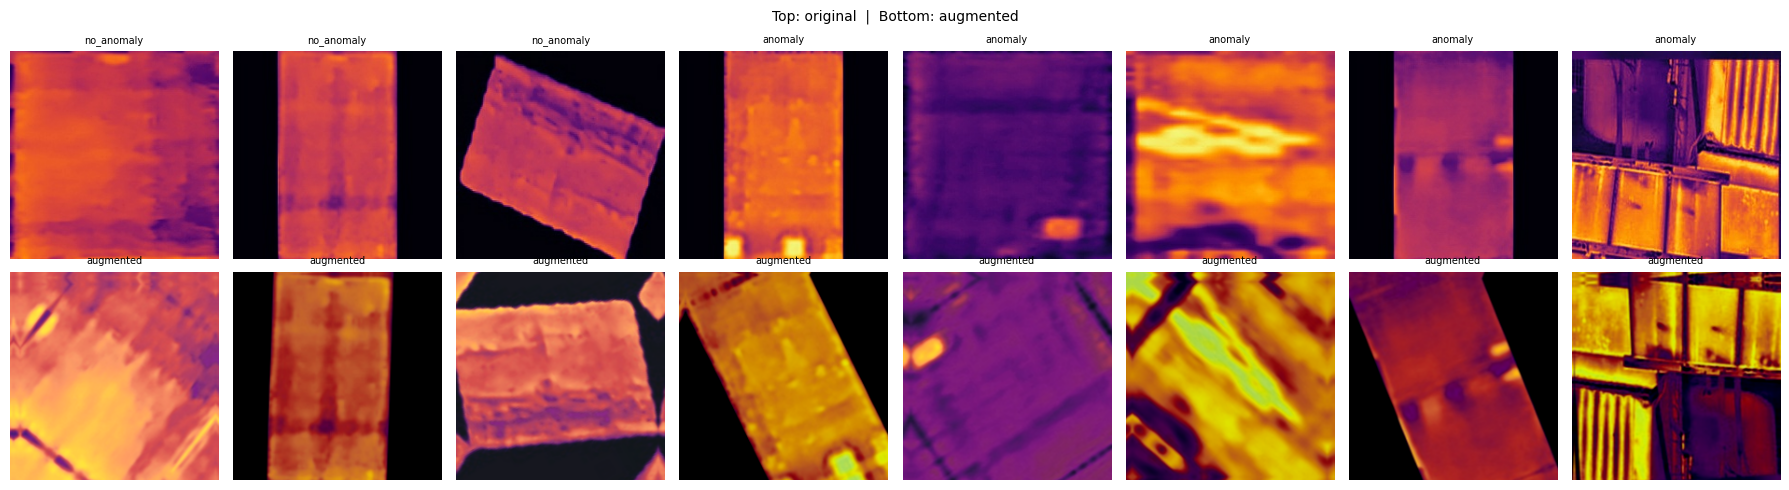

In [29]:
# ── Preprocessing: scale to [-1, 1] (MobileNetV2 convention) ─────────────────
preprocess = keras.applications.mobilenet_v2.preprocess_input  # maps [0,255]→[-1,1]

# ── Keras augmentation layers (applied on GPU, inside tf.data) ───────────────
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),           # ±15 % of 360°
    layers.RandomZoom(0.10),               # ±10 %
    layers.RandomTranslation(0.05, 0.05),  # slight shifts
    # Colormap-aware jitter: hue shift bridges iron↔rainbow domain gap
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name='augmentation')

# RandomHue is not built-in in older TF; use tf.image directly:
@tf.function
def augment_hue(image, label):
    """Slight hue rotation to simulate different thermal colourmap palettes."""
    image = tf.cast(image, tf.float32)
    # Random hue delta in [-0.08, 0.08] — enough to shift iron→rainbow, not so
    # much that hot/cold polarity inverts
    image = tf.image.random_hue(image / 255.0, max_delta=0.08) * 255.0
    return tf.clip_by_value(image, 0.0, 255.0), label

def build_pipeline(ds, training=False):
    AUTOTUNE = tf.data.AUTOTUNE
    if training:
        ds = ds.map(augment_hue, num_parallel_calls=AUTOTUNE)
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    # Preprocess to [-1, 1]
    ds = ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = build_pipeline(train_ds_raw, training=True)
val_ds   = build_pipeline(val_ds_raw,   training=False)
test_ds  = build_pipeline(test_ds_raw,  training=False)

print('Pipelines built.')

# ── Visualise one augmented batch ─────────────────────────────────────────────
sample_images, sample_labels = next(iter(train_ds_raw.take(1)))
aug_images, _ = augment_hue(sample_images[:8], sample_labels[:8])
aug_images = augmentation(aug_images, training=True)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    axes[0, i].imshow(sample_images[i].numpy().astype('uint8'))
    axes[0, i].set_title(CLASSES[int(sample_labels[i])], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(tf.clip_by_value(aug_images[i], 0, 255).numpy().astype('uint8'))
    axes[1, i].set_title('augmented', fontsize=7)
    axes[1, i].axis('off')
fig.suptitle('Top: original  |  Bottom: augmented', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_preview.png', dpi=120)
plt.show()

## 4 — Model Architecture

In [30]:
def build_model(trainable_base=False):
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        alpha=1.0,           # full-width model
        include_top=False,
        weights='imagenet',
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)          # BN layers stay in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)   # binary

    model = keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model(trainable_base=False)
model.summary(line_length=90)
print(f'\nTrainable params: {model.trainable_variables.__len__()} tensors')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2            │ (None, 1280)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 1280)                 │           5,120 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                   │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                       │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                       │ (None, 1)                    │             257 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Trainable params: 6 tensors


## 5 — Training

Three-phase progressive unfreezing:

| Phase | Layers trained | LR |
|-------|----------------|----|
| 1 | Head only | 1e-3 |
| 2 | Head + top 1/3 of base | 3e-4 |
| 3 | Full network | 5e-5 |

In [31]:
def get_callbacks(phase_name):
    return [
        callbacks.ModelCheckpoint(
            str(OUTPUT_DIR / f'best_{phase_name}.keras'),
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_auc', mode='max',
            patience=5, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        ),
    ]

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

history_all = {}

In [32]:
# ── Phase 1: Train head only ──────────────────────────────────────────────────
print('=' * 60)
print('PHASE 1 — Head only')
print('=' * 60)

base_model.trainable = False
compile_model(model, LR_HEAD)

h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=get_callbacks('phase1'),
    verbose=1,
)
history_all['phase1'] = h1.history

PHASE 1 — Head only
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7061 - auc: 0.7832 - loss: 0.7382 - precision: 0.6312 - recall: 0.7127
Epoch 1: val_auc improved from None to 0.87786, saving model to /kaggle/working/best_phase1.keras

Epoch 1: finished saving model to /kaggle/working/best_phase1.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 267ms/step - accuracy: 0.7388 - auc: 0.8164 - loss: 0.6761 - precision: 0.6700 - recall: 0.7576 - val_accuracy: 0.7207 - val_auc: 0.8779 - val_loss: 0.6444 - val_precision: 0.6102 - val_recall: 0.9474 - learning_rate: 0.0010
Epoch 2/10
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7678 - auc: 0.8463 - loss: 0.5869 - precision: 0.6955 - recall: 0.7966
Epoch 2: val_auc improved from 0.87786 to 0.90362, saving model to /kaggle/working/best_phase1.keras

Epoch 2: finished saving model to /kaggle/working/best_phase1.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 53s 221ms/step - accuracy: 0.7760 - auc: 0.8542 - loss: 0.5648 - precision: 0.

In [34]:
print('=' * 60)
print('PHASE 2 — Top 1/3 of base unfrozen')
print('=' * 60)
 
# FIX 1: Always reload the best Phase 1 checkpoint before touching the base.
# Continuing from the end-of-training state risks starting from a worse point.
model = keras.models.load_model(str(OUTPUT_DIR / 'best_phase1.keras'))
print('Loaded best Phase 1 checkpoint.')
 
# Recover the base sub-model by name
base_model = model.get_layer('mobilenetv2_1.00_224')   # default Keras name
 
base_model.trainable = True
n_layers     = len(base_model.layers)
freeze_until = int(n_layers * 2 / 3)          # keep bottom 2/3 frozen
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
# FIX 2: Always keep BN layers frozen — they carry ImageNet statistics.
# Unfreezing them with a small dataset causes severe instability.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
 
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'  Base layers: {n_layers} | frozen: {n_layers - trainable_count} | trainable: {trainable_count}')
 
# FIX 3: Lower LR (1e-4 instead of 3e-4) — freshly unfrozen weights are
# sensitive; a large first step destroys the Phase 1 representations.
compile_model(model, lr=1e-4)
 
# FIX 4: Optimizer warm-up — run 1 epoch with the base still FROZEN so Adam
# can accumulate gradient statistics before it touches the base weights.
# This prevents the first-step catastrophic update.
print('\n  [Warm-up] 1 epoch with base frozen to stabilise Adam accumulators...')
for layer in base_model.layers:
    layer.trainable = False
model.fit(
    train_ds, validation_data=val_ds,
    epochs=1, class_weight=class_weight,
    verbose=1,
)
# Now unfreeze top 1/3 again (BN stays frozen)
for i, layer in enumerate(base_model.layers):
    if i >= freeze_until and not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
# Recompile to register the new trainable graph
compile_model(model, lr=1e-4)
print('  [Warm-up done] Base top-1/3 unfrozen, resuming fine-tuning.\n')
 
h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE1,
    class_weight=class_weight,
    callbacks=get_callbacks('phase2'),
    verbose=1,
)
history_all['phase2'] = h2.history


PHASE 2 — Top 1/3 of base unfrozen
Loaded best Phase 1 checkpoint.
  Base layers: 154 | frozen: 120 | trainable: 34

  [Warm-up] 1 epoch with base frozen to stabilise Adam accumulators...
235/235 ━━━━━━━━━━━━━━━━━━━━ 76s 268ms/step - accuracy: 0.8069 - auc: 0.8944 - loss: 0.4836 - precision: 0.7351 - recall: 0.8520 - val_accuracy: 0.7827 - val_auc: 0.9396 - val_loss: 0.5144 - val_precision: 0.6647 - val_recall: 0.9854
  [Warm-up done] Base top-1/3 unfrozen, resuming fine-tuning.

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7856 - auc: 0.8702 - loss: 0.5199 - precision: 0.7068 - recall: 0.8380
Epoch 1: val_auc improved from None to 0.96154, saving model to /kaggle/working/best_phase2.keras

Epoch 1: finished saving model to /kaggle/working/best_phase2.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 274ms/step - accuracy: 0.8109 - auc: 0.8950 - loss: 0.4847 - precision: 0.7317 - recall: 0.8755 - val_accuracy: 0.6530 - val_auc: 0.9615 - val_loss: 0.8202 - val_precision: 0.5

In [35]:
# ── Phase 3: Unfreeze full base ───────────────────────────────────────────────
print('=' * 60)
print('PHASE 3 — Full network fine-tuned')
print('=' * 60)
 
# FIX 1 (again): reload best Phase 2 checkpoint
best_p2 = OUTPUT_DIR / 'best_phase2.keras'
if best_p2.exists():
    model = keras.models.load_model(str(best_p2))
    base_model = model.get_layer('mobilenetv2_1.00_224')
    print('Loaded best Phase 2 checkpoint.')
 
# Unfreeze everything except BN
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True
 
print(f'  Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')
 
# FIX 3: Very low LR for full fine-tuning
compile_model(model, lr=5e-5)
 
# FIX 4: Warm-up epoch (frozen base) before full fine-tune
print('\n  [Warm-up] 1 epoch frozen...')
for layer in base_model.layers:
    layer.trainable = False
model.fit(
    train_ds, validation_data=val_ds,
    epochs=1, class_weight=class_weight,
    verbose=1,
)
for layer in base_model.layers:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
compile_model(model, lr=5e-5)
print('  [Warm-up done]\n')
 
h3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE2,
    class_weight=class_weight,
    callbacks=get_callbacks('phase3'),
    verbose=1,
)
history_all['phase3'] = h3.history

PHASE 3 — Full network fine-tuned
Loaded best Phase 2 checkpoint.
  Trainable layers: 102 / 154

  [Warm-up] 1 epoch frozen...
235/235 ━━━━━━━━━━━━━━━━━━━━ 73s 260ms/step - accuracy: 0.8937 - auc: 0.9554 - loss: 0.3645 - precision: 0.8458 - recall: 0.9166 - val_accuracy: 0.9367 - val_auc: 0.9855 - val_loss: 0.2892 - val_precision: 0.8829 - val_recall: 0.9810
  [Warm-up done]

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8731 - auc: 0.9449 - loss: 0.3815 - precision: 0.8007 - recall: 0.9324
Epoch 1: val_auc improved from None to 0.98280, saving model to /kaggle/working/best_phase3.keras

Epoch 1: finished saving model to /kaggle/working/best_phase3.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 312ms/step - accuracy: 0.8836 - auc: 0.9492 - loss: 0.3721 - precision: 0.8163 - recall: 0.9363 - val_accuracy: 0.9174 - val_auc: 0.9828 - val_loss: 0.3399 - val_precision: 0.8397 - val_recall: 0.9956 - learning_rate: 5.0000e-05
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/ste

## 6 — Training Curves

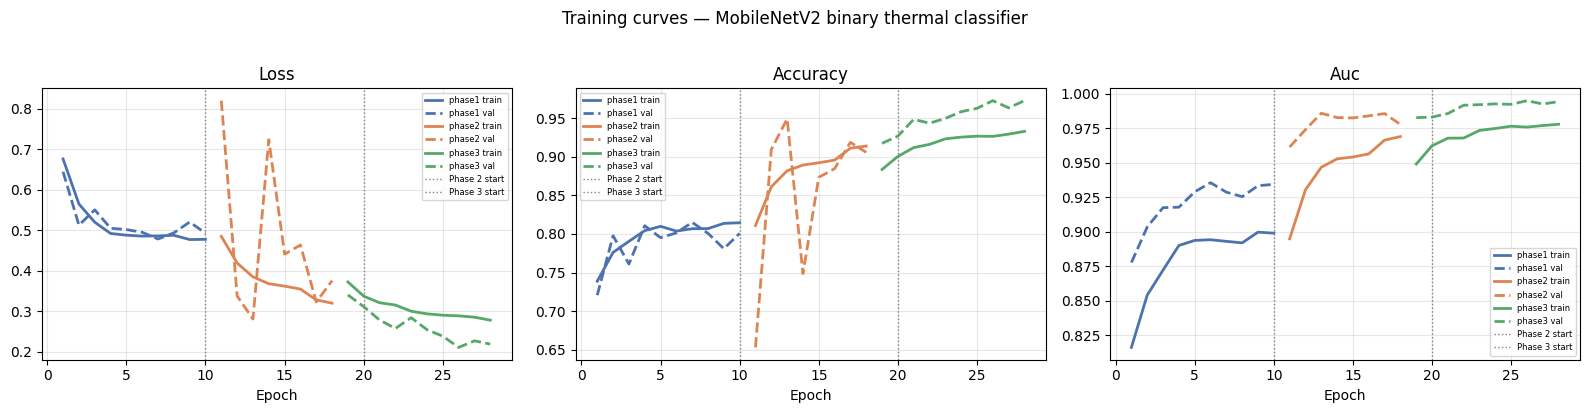

In [36]:
def plot_history(history_all):
    metrics = ['loss', 'accuracy', 'auc']
    phase_colors = {'phase1': '#4C72B0', 'phase2': '#DD8452', 'phase3': '#55A868'}

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    offset = 0
    for phase, hist in history_all.items():
        n = len(hist['loss'])
        epochs = range(offset + 1, offset + n + 1)
        color  = phase_colors[phase]
        for ax, metric in zip(axes, metrics):
            ax.plot(epochs, hist[metric],       color=color,  lw=2,   label=f'{phase} train')
            ax.plot(epochs, hist[f'val_{metric}'], color=color, lw=2, ls='--', label=f'{phase} val')
        offset += n

    # Vertical lines at phase boundaries
    boundaries = [EPOCHS_HEAD, EPOCHS_HEAD + EPOCHS_FINE1]
    for b, label in zip(boundaries, ['Phase 2 start', 'Phase 3 start']):
        for ax in axes:
            ax.axvline(b, color='grey', ls=':', lw=1, label=label)

    for ax, metric in zip(axes, metrics):
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=6)
        ax.grid(alpha=0.3)

    plt.suptitle('Training curves — MobileNetV2 binary thermal classifier', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_all)

## 7 — Evaluation on Test Set

In [37]:
# Load best checkpoint from Phase 3 (or whichever achieved best val_auc)
best_ckpt = OUTPUT_DIR / 'best_phase3.keras'
if not best_ckpt.exists():
    best_ckpt = OUTPUT_DIR / 'best_phase2.keras'
model = keras.models.load_model(str(best_ckpt))
print(f'Loaded checkpoint: {best_ckpt}')

# ── Collect predictions ───────────────────────────────────────────────────────
y_true, y_prob = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0).flatten()
    y_true.extend(labels.numpy().astype(int).flatten())
    y_prob.extend(probs)

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────────
print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

auc = roc_auc_score(y_true, y_prob)
print(f'ROC-AUC: {auc:.4f}')

Loaded checkpoint: /kaggle/working/best_phase3.keras


2026-06-07 13:21:26.187011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 13:21:26.323053: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



── Classification Report ──
              precision    recall  f1-score   support

     anomaly     0.9751    0.9688    0.9719       929
  no_anomaly     0.9580    0.9664    0.9622       684

    accuracy                         0.9678      1613
   macro avg     0.9665    0.9676    0.9670      1613
weighted avg     0.9678    0.9678    0.9678      1613

ROC-AUC: 0.9933


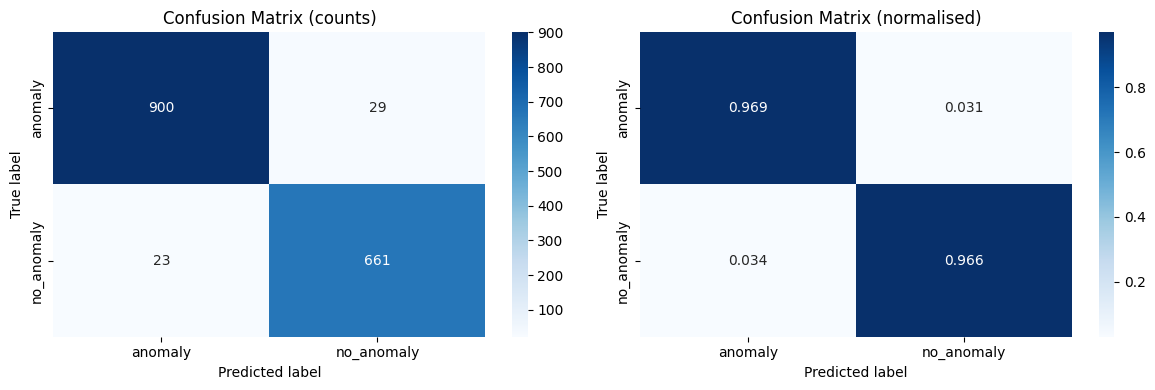

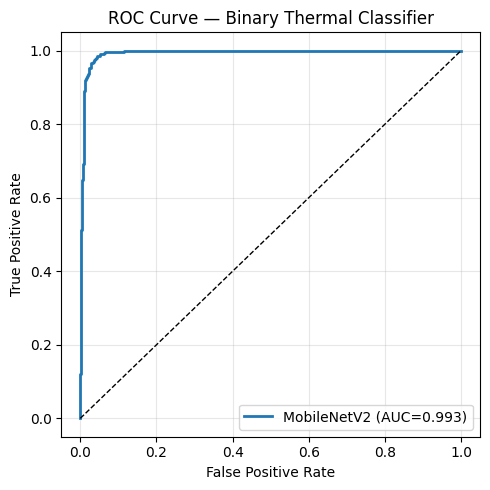

In [38]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label=f'MobileNetV2 (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Binary Thermal Classifier')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150)
plt.show()

## 8 — TFLite Float16 Export (Pi 5)

In [40]:
# ── Save full Keras model first ───────────────────────────────────────────────
keras_path = str(OUTPUT_DIR / 'thermal_binary_mobilenetv2.keras')
model.save(keras_path)
print(f'Keras model saved: {keras_path}')

# ── Convert to TFLite float16 ─────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
# Keep input/output as float32 for easy inference on Pi 5
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

tflite_path = OUTPUT_DIR / 'thermal_binary_mobilenetv2_f16.tflite'
tflite_path.write_bytes(tflite_model)
print(f'TFLite model saved: {tflite_path}')
print(f'  Size: {tflite_path.stat().st_size / 1024 / 1024:.2f} MB')

# ── Verify TFLite model ───────────────────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()
inp  = interpreter.get_input_details()
outp = interpreter.get_output_details()
print(f'\nTFLite input  : shape={inp[0]["shape"]}, dtype={inp[0]["dtype"]}')
print(f'TFLite output : shape={outp[0]["shape"]}, dtype={outp[0]["dtype"]}')

Keras model saved: /kaggle/working/thermal_binary_mobilenetv2.keras
INFO:tensorflow:Assets written to: /tmp/tmp9y8h75fh/assets


INFO:tensorflow:Assets written to: /tmp/tmp9y8h75fh/assets


Saved artifact at '/tmp/tmp9y8h75fh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134316505559888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505559120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505560656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505561808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505547024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505562192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505558352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505547216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505560080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134316505559696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1343165055468

W0000 00:00:1780839133.926236      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780839133.926297      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780839134.076093      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [41]:
# ── Benchmark TFLite on a batch of test images ────────────────────────────────
import time

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()
inp_idx  = interpreter.get_input_details()[0]['index']
outp_idx = interpreter.get_output_details()[0]['index']

# Single-image inference time
sample_batch, _ = next(iter(test_ds.take(1)))
single_img = sample_batch[0:1].numpy().astype(np.float32)

times = []
for _ in range(50):
    t0 = time.perf_counter()
    interpreter.set_tensor(inp_idx, single_img)
    interpreter.invoke()
    _ = interpreter.get_tensor(outp_idx)
    times.append((time.perf_counter() - t0) * 1000)

print(f'TFLite inference time (50 runs, single image):')
print(f'  Mean : {np.mean(times):.1f} ms')
print(f'  Std  : {np.std(times):.1f} ms')
print(f'  Min  : {np.min(times):.1f} ms')
print(f'  Max  : {np.max(times):.1f} ms')
print('\n(Kaggle T4 GPU times; expect ~5-8× slower on Pi 5 CPU)')

TFLite inference time (50 runs, single image):
  Mean : 7.7 ms
  Std  : 0.5 ms
  Min  : 6.9 ms
  Max  : 9.2 ms

(Kaggle T4 GPU times; expect ~5-8× slower on Pi 5 CPU)


## 9 — Save Metadata & Outputs

In [42]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

metadata = {
    'model'        : 'MobileNetV2',
    'alpha'        : 1.0,
    'input_size'   : [IMG_SIZE, IMG_SIZE, 3],
    'classes'      : CLASSES,
    'class_weight' : {str(k): float(v) for k, v in class_weight.items()},
    'test_metrics' : {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'macro_f1' : float(f1_score(y_true, y_pred, average='macro')),
        'precision': float(precision_score(y_true, y_pred, average='macro')),
        'recall'   : float(recall_score(y_true, y_pred, average='macro')),
        'roc_auc'  : float(auc),
    },
    'tflite_path'  : 'thermal_binary_mobilenetv2_f16.tflite',
    'preprocessing': 'mobilenet_v2.preprocess_input  # [0,255]→[-1,1]',
}

meta_path = OUTPUT_DIR / 'model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved metadata:')
print(json.dumps(metadata, indent=2))

print('\n── Output files ──')
for p in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {p.name:50s}  {p.stat().st_size/1024:.1f} KB')

Saved metadata:
{
  "model": "MobileNetV2",
  "alpha": 1.0,
  "input_size": [
    224,
    224,
    3
  ],
  "classes": [
    "anomaly",
    "no_anomaly"
  ],
  "class_weight": {
    "0": 0.8685852981969486,
    "1": 1.17826904985889
  },
  "test_metrics": {
    "accuracy": 0.967761934283943,
    "macro_f1": 0.9670382701261628,
    "precision": 0.9665261356320756,
    "recall": 0.9675789536633115,
    "roc_auc": 0.9933242686911035
  },
  "tflite_path": "thermal_binary_mobilenetv2_f16.tflite",
  "preprocessing": "mobilenet_v2.preprocess_input  # [0,255]\u2192[-1,1]"
}

── Output files ──
  .virtual_documents                                  4.0 KB
  augmentation_preview.png                            1084.0 KB
  best_model_phase1.h5                                9824.8 KB
  best_phase1.keras                                   13295.1 KB
  best_phase2.keras                                   27633.3 KB
  best_phase3.keras                                   30433.4 KB
  confusion_matrix.png

In [43]:
# Compare TFLite vs Original Model Accuracy
print("=== TFLITE ACCURACY VALIDATION ===\n")

# Get predictions from TFLite model
tflite_interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
tflite_interpreter.allocate_tensors()
inp_idx = tflite_interpreter.get_input_details()[0]['index']
outp_idx = tflite_interpreter.get_output_details()[0]['index']

tflite_preds = []
for images, labels in test_ds.take(50):  # Test on 50 batches
    for i in range(len(images)):
        img = images[i:i+1].numpy().astype(np.float32)
        tflite_interpreter.set_tensor(inp_idx, img)
        tflite_interpreter.invoke()
        pred = tflite_interpreter.get_tensor(outp_idx)[0][0]
        tflite_preds.append(pred)

# Compare with original model
original_preds = y_prob[:len(tflite_preds)]

# Calculate difference
diff = np.abs(np.array(original_preds) - np.array(tflite_preds))
print(f"Mean prediction difference: {np.mean(diff):.6f}")
print(f"Max prediction difference: {np.max(diff):.6f}")
print(f"Predictions match within 1%: {(diff < 0.01).mean()*100:.1f}%")

# If differences are tiny (<0.001), TFLite conversion was successful!

=== TFLITE ACCURACY VALIDATION ===

Mean prediction difference: 0.000500
Max prediction difference: 0.014260
Predictions match within 1%: 99.7%



=== MISCLASSIFICATION ANALYSIS ===

False Positives (normal → anomaly): 16
False Negatives (anomaly → normal): 0


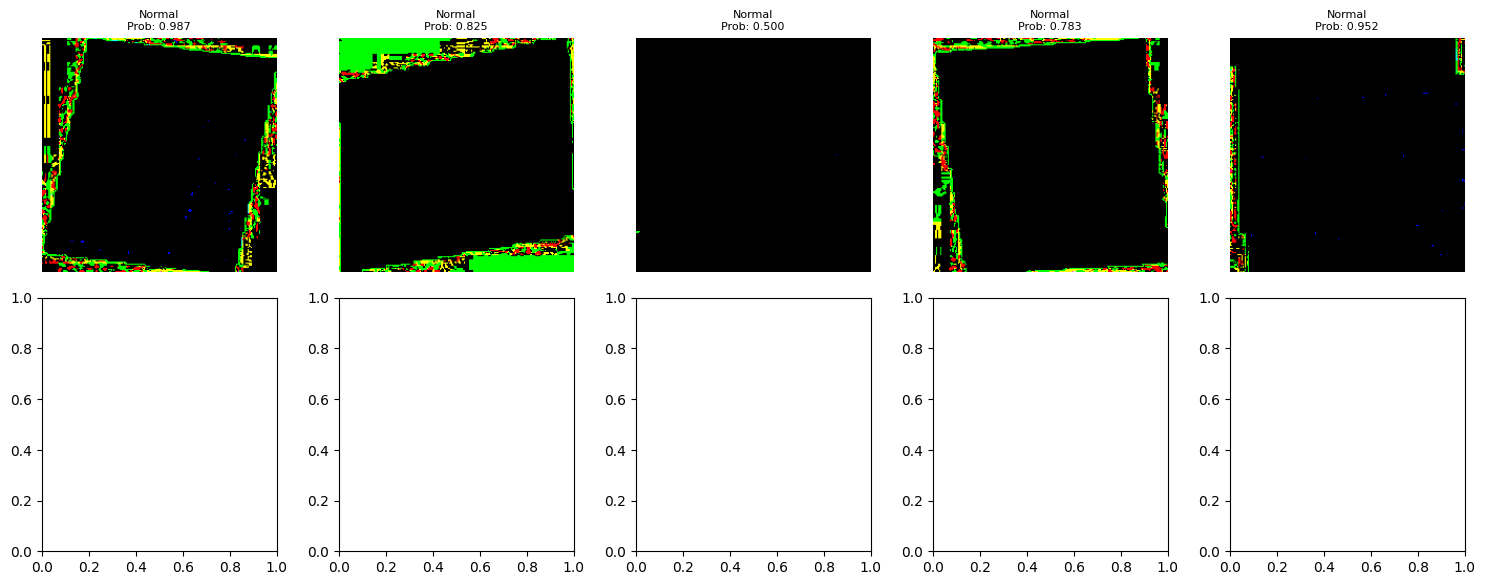

In [44]:
# Find misclassified examples to understand failure modes
print("\n=== MISCLASSIFICATION ANALYSIS ===\n")

# Get batch with predictions
test_images = []
test_labels = []
test_probs = []

for images, labels in test_ds.take(20):  # Sample 20 batches
    probs = model.predict(images, verbose=0).flatten()
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())
    test_probs.extend(probs)

test_labels = np.array(test_labels)
test_probs = np.array(test_probs)
test_preds = (test_probs >= 0.5).astype(int)

# Find misclassifications
false_positives = np.where((test_preds == 1) & (test_labels == 0))[0]  # Normal classified as anomaly
false_negatives = np.where((test_preds == 0) & (test_labels == 1))[0]  # Anomaly missed

print(f"False Positives (normal → anomaly): {len(false_positives)}")
print(f"False Negatives (anomaly → normal): {len(false_negatives)}")

# Visualize a few misclassifications
if len(false_positives) > 0:
    fig, axes = plt.subplots(2, min(5, len(false_positives)), figsize=(15, 6))
    for i, idx in enumerate(false_positives[:5]):
        img = test_images[idx].astype('uint8')
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Normal\nProb: {test_probs[idx]:.3f}", fontsize=8)
        axes[0, i].axis('off')
    axes[0, 0].set_ylabel("False Positives", fontsize=10)

if len(false_negatives) > 0:
    fig, axes = plt.subplots(2, min(5, len(false_negatives)), figsize=(15, 6))
    for i, idx in enumerate(false_negatives[:5]):
        img = test_images[idx].astype('uint8')
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Anomaly (missed)\nProb: {test_probs[idx]:.3f}", fontsize=8)
        axes[1, i].axis('off')
    axes[1, 0].set_ylabel("False Negatives", fontsize=10)

plt.tight_layout()
plt.show()


=== CONFIDENCE CALIBRATION (FIXED) ===



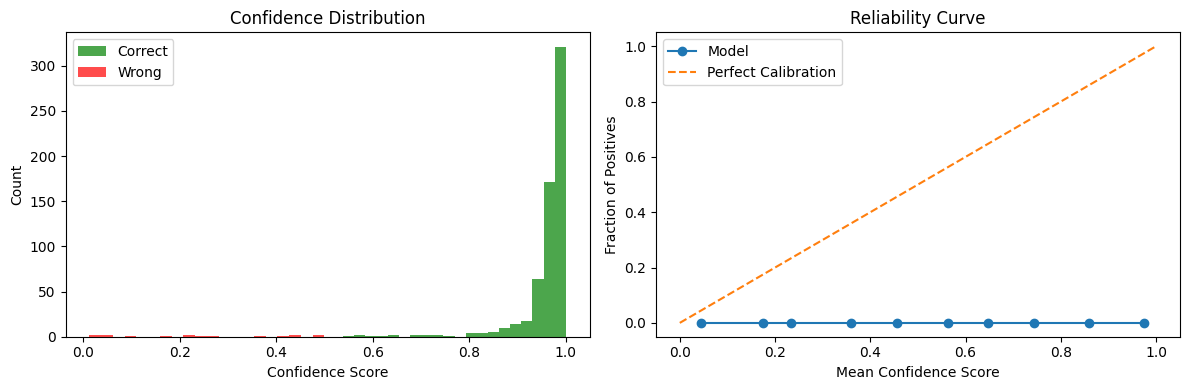

Average confidence when correct: 0.961
Average confidence when wrong: 0.248


In [50]:
# CORRECTED: Confidence Calibration
print("\n=== CONFIDENCE CALIBRATION (FIXED) ===\n")

# Convert probabilities to confidence scores
# For anomaly (class 0): confidence = 1 - probability
# For normal (class 1): confidence = probability
confidence_scores = np.where(test_labels == 0, 1 - test_probs, test_probs)

correct_preds_conf = confidence_scores[test_preds == test_labels]
wrong_preds_conf = confidence_scores[test_preds != test_labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of confidence scores
axes[0].hist(correct_preds_conf, bins=20, alpha=0.7, label='Correct', color='green')
if len(wrong_preds_conf) > 0:
    axes[0].hist(wrong_preds_conf, bins=20, alpha=0.7, label='Wrong', color='red')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution')
axes[0].legend()

# Reliability diagram (using confidence scores)
from sklearn.calibration import calibration_curve
# Convert to confidence scores and ensure they're in [0,1]
conf_scores_for_calib = np.where(test_labels == 0, 1 - test_probs, test_probs)
prob_true, prob_pred = calibration_curve(test_labels, conf_scores_for_calib, n_bins=10)
axes[1].plot(prob_pred, prob_true, marker='o', label='Model')
axes[1].plot([0, 1], [0, 1], '--', label='Perfect Calibration')
axes[1].set_xlabel('Mean Confidence Score')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Reliability Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average confidence when correct: {np.mean(correct_preds_conf):.3f}")
print(f"Average confidence when wrong: {np.mean(wrong_preds_conf):.3f}" if len(wrong_preds_conf) > 0 else "No wrong predictions in sample")

In [49]:
# DIAGNOSTIC: Check label mapping
print("\n=== LABEL MAPPING VERIFICATION ===\n")

# Get one batch and inspect
for images, labels in test_ds.take(1):
    print(f"Label values in batch: {labels[:10].numpy().flatten()}")
    print(f"Unique labels: {np.unique(labels.numpy())}")
    
# Check your class definitions
print(f"\nCLASSES variable: {CLASSES}")
print(f"Class weight mapping: {class_weight}")

# Verify what 0 and 1 mean
print("\nAccording to your setup:")
print(f"  Label 0 = {CLASSES[0]} (anomaly)")
print(f"  Label 1 = {CLASSES[1]} (no_anomaly)")

# Check a few predictions
sample_images, sample_labels = next(iter(test_ds.take(1)))
sample_probs = model.predict(sample_images[:5], verbose=0).flatten()

for i in range(5):
    true_class = "anomaly" if sample_labels[i] == 0 else "no_anomaly"
    pred_class = "anomaly" if sample_probs[i] < 0.5 else "no_anomaly"
    print(f"Sample {i}: True={true_class} (label={sample_labels[i]:.0f}), "
          f"Pred prob={sample_probs[i]:.3f} → {pred_class}")


=== LABEL MAPPING VERIFICATION ===

Label values in batch: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Unique labels: [0.]

CLASSES variable: ['anomaly', 'no_anomaly']
Class weight mapping: {0: np.float64(0.8685852981969486), 1: np.float64(1.17826904985889)}

According to your setup:
  Label 0 = anomaly (anomaly)
  Label 1 = no_anomaly (no_anomaly)


2026-06-07 13:54:01.478065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 13:54:01.624662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Sample 0: True=anomaly (label=0), Pred prob=0.046 → anomaly
Sample 1: True=anomaly (label=0), Pred prob=0.014 → anomaly
Sample 2: True=anomaly (label=0), Pred prob=0.004 → anomaly
Sample 3: True=anomaly (label=0), Pred prob=0.050 → anomaly
Sample 4: True=anomaly (label=0), Pred prob=0.058 → anomaly


In [46]:
from sklearn.metrics import f1_score, precision_recall_curve

print("\n=== THRESHOLD OPTIMIZATION ===\n")

# Find optimal threshold for different objectives
precisions, recalls, thresholds = precision_recall_curve(test_labels, test_probs)

# Objective 1: Maximize F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_f1_idx = np.argmax(f1_scores[:-1])
optimal_f1_thresh = thresholds[optimal_f1_idx]

# Objective 2: Maximize Precision (minimize false alarms)
high_prec_idx = np.where(precisions > 0.98)[0]
high_prec_thresh = thresholds[high_prec_idx[0]] if len(high_prec_idx) > 0 else 0.5

# Objective 3: Maximize Recall (catch all anomalies)
high_recall_idx = np.where(recalls > 0.99)[0]
high_recall_thresh = thresholds[high_recall_idx[0]] if len(high_recall_idx) > 0 else 0.5

print(f"Default threshold (0.5): F1={f1_score(test_labels, test_preds):.4f}")
print(f"Optimal F1 threshold: {optimal_f1_thresh:.3f} (F1={f1_scores[optimal_f1_idx]:.4f})")
print(f"High precision threshold: {high_prec_thresh:.3f} (Fewer false alarms)")
print(f"High recall threshold: {high_recall_thresh:.3f} (Catch more anomalies)")

# Recommendation based on PV inspection
print("\n🎯 RECOMMENDATION for PV inspection:")
print(f"   Use threshold = {optimal_f1_thresh:.3f} for balanced performance")
print(f"   OR threshold = {high_recall_thresh:.3f} if missing anomalies is costly")


=== THRESHOLD OPTIMIZATION ===



IndexError: index 637 is out of bounds for axis 0 with size 637

## 10 — Pi 5 Inference Snippet

Copy `thermal_binary_mobilenetv2_f16.tflite` to the Pi 5 and use this snippet inside the main pipeline:

In [47]:
PI5_INFERENCE_SNIPPET = '''
# ── Pi 5 inference — drop-in for existing ONNX classifier call ───────────────
import numpy as np
import cv2
from tflite_runtime.interpreter import Interpreter   # pip install tflite-runtime

IMG_SIZE = 224
THRESHOLD = 0.5

# Load once at startup
interpreter = Interpreter(model_path="thermal_binary_mobilenetv2_f16.tflite")
interpreter.allocate_tensors()
inp_idx  = interpreter.get_input_details()[0]["index"]
outp_idx = interpreter.get_output_details()[0]["index"]

def preprocess_thermal(bgr_crop):
    """BGR crop from TC002C stream → model input tensor."""
    rgb = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    # MobileNetV2 preprocessing: [0,255] → [-1, 1]
    tensor = (resized.astype(np.float32) / 127.5) - 1.0
    return np.expand_dims(tensor, axis=0)   # (1, 224, 224, 3)

def classify_thermal(bgr_crop):
    """Returns (label_str, confidence_float)."""
    tensor = preprocess_thermal(bgr_crop)
    interpreter.set_tensor(inp_idx, tensor)
    interpreter.invoke()
    prob = float(interpreter.get_tensor(outp_idx)[0][0])
    label = "no_anomaly" if prob >= THRESHOLD else "anomaly"
    conf  = prob if prob >= THRESHOLD else 1.0 - prob
    return label, conf
'''

snippet_path = OUTPUT_DIR / 'pi5_inference_snippet.py'
snippet_path.write_text(PI5_INFERENCE_SNIPPET)
print('Pi 5 snippet saved.')
print(PI5_INFERENCE_SNIPPET)

Pi 5 snippet saved.

# ── Pi 5 inference — drop-in for existing ONNX classifier call ───────────────
import numpy as np
import cv2
from tflite_runtime.interpreter import Interpreter   # pip install tflite-runtime

IMG_SIZE = 224
THRESHOLD = 0.5

# Load once at startup
interpreter = Interpreter(model_path="thermal_binary_mobilenetv2_f16.tflite")
interpreter.allocate_tensors()
inp_idx  = interpreter.get_input_details()[0]["index"]
outp_idx = interpreter.get_output_details()[0]["index"]

def preprocess_thermal(bgr_crop):
    """BGR crop from TC002C stream → model input tensor."""
    rgb = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    # MobileNetV2 preprocessing: [0,255] → [-1, 1]
    tensor = (resized.astype(np.float32) / 127.5) - 1.0
    return np.expand_dims(tensor, axis=0)   # (1, 224, 224, 3)

def classify_thermal(bgr_crop):
    """Returns (label_str, confidence_float)."""
    tensor = preprocess_ther